#Load & Preprocess

##Install & Import All Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


# Explore Dataset



In [24]:
df = pd.read_csv('insurance.csv')

In [25]:
print(df.shape)   #For shape

(1338, 7)


In [26]:
print(df.head())   #First 5 Values

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [27]:
print(df.dtypes)    #Tyoes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [28]:
print("\n── Statistical Summary ─────────────────")
print(df.describe())


── Statistical Summary ─────────────────
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [29]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [30]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [31]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [32]:
print(df.duplicated().sum())           # Check duplicates

1


In [33]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#  Data Preprocessing

In [35]:
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])       # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])    # no=0, yes=1

In [36]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [37]:
print("── Encoded DataFrame ───────────────────")
print(df.head())
print(f"\nFinal shape: {df.shape}")    # (1338, 9)
print(f"Columns: {df.columns.tolist()}")

── Encoded DataFrame ───────────────────
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Final shape: (1338, 9)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


# Exploratory Data Analysis (EDA)

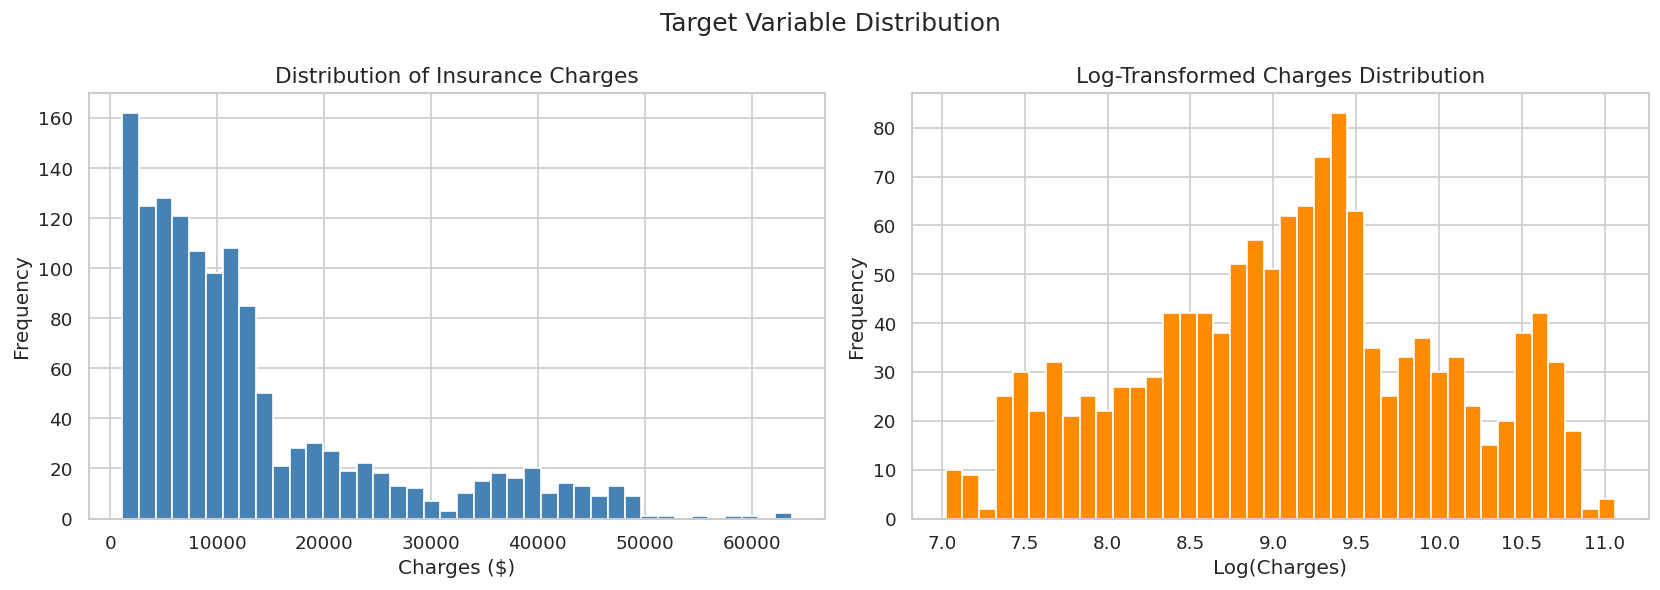

In [41]:
#Distribution of Target Variable (charges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log(df['charges']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Charges Distribution')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=15)
plt.tight_layout()
plt.show()

Original is right-skewed; log transform makes it more normal

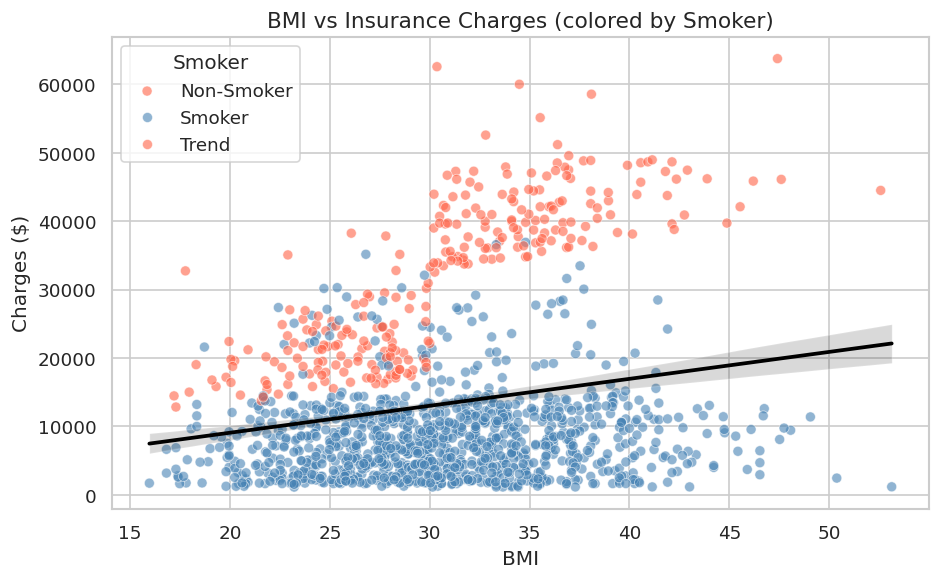

In [42]:
#BMI vs Charges

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges',
                hue='smoker', palette={0:'steelblue', 1:'tomato'},
                alpha=0.6)
sns.regplot(data=df, x='bmi', y='charges',
            scatter=False, color='black', label='Overall Trend')
plt.title('BMI vs Insurance Charges (colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker', labels=['Non-Smoker', 'Smoker', 'Trend'])
plt.tight_layout()
plt.show()


Smokers with high BMI have dramatically higher charges

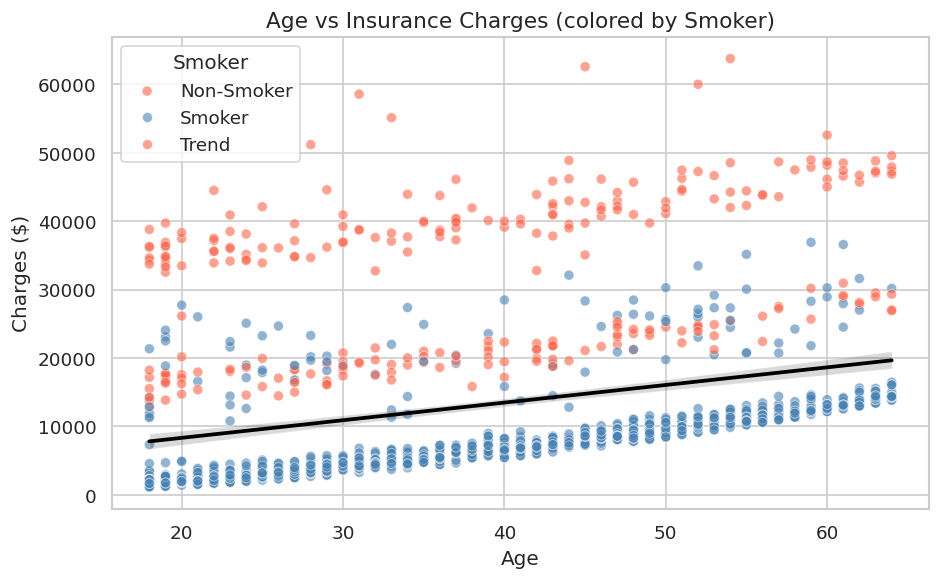

In [43]:
#  Age vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges',
                hue='smoker', palette={0:'steelblue', 1:'tomato'},
                alpha=0.6)
sns.regplot(data=df, x='age', y='charges',
            scatter=False, color='black', label='Overall Trend')
plt.title('Age vs Insurance Charges (colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker', labels=['Non-Smoker', 'Smoker', 'Trend'])
plt.tight_layout()
plt.show()

Observation: Three visible bands — charges increase with age Smokers consistently pay far more at every age

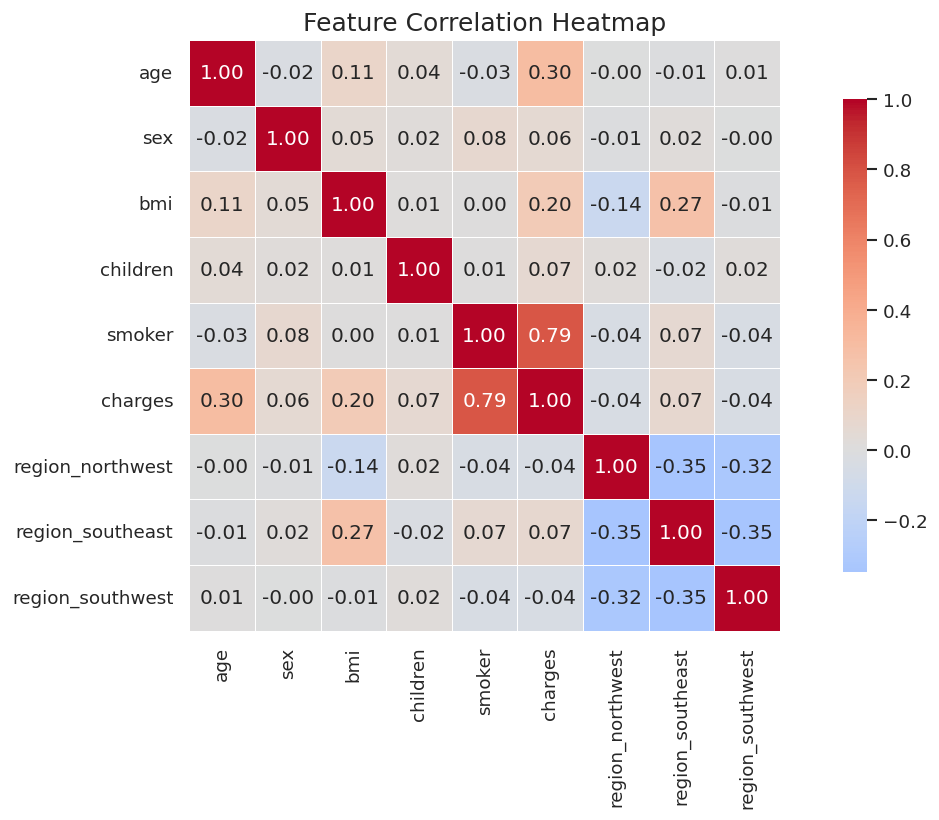

In [47]:
#Correlation Heatmap
plt.figure(figsize=(11, 7))
corr = df.corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

Observation: smoker (0.79), age (0.30), bmi (0.20) are top correlator

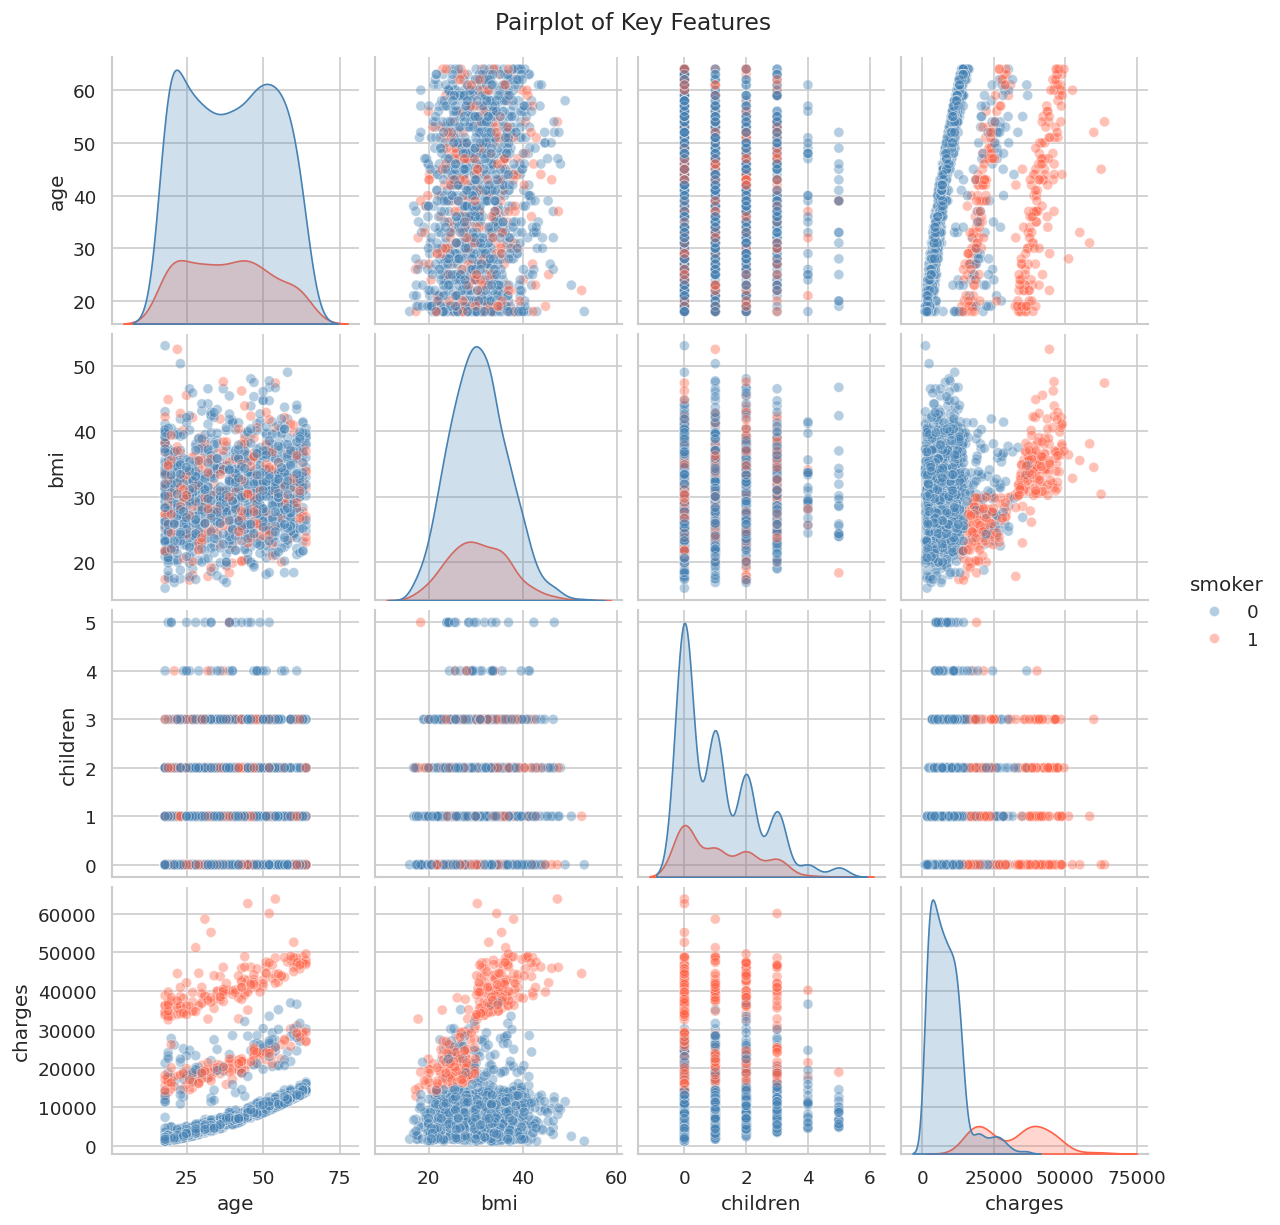

In [48]:
sns.pairplot(df[['age', 'bmi', 'children', 'charges', 'smoker']],
             hue='smoker',
             palette={0:'steelblue', 1:'tomato'},
             plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14)
plt.show()

# Feature Engineering

In [49]:
df['bmi_smoker'] = df['bmi'] * df['smoker']

In [50]:
df['age_squared'] = df['age'] ** 2

In [51]:
print("── New Features Added ──────────────────")
print(df[['bmi', 'smoker', 'bmi_smoker', 'age', 'age_squared']].head())
print(f"\nFinal shape: {df.shape}")

── New Features Added ──────────────────
      bmi  smoker  bmi_smoker  age  age_squared
0  27.900       1        27.9   19          361
1  33.770       0         0.0   18          324
2  33.000       0         0.0   28          784
3  22.705       0         0.0   33         1089
4  28.880       0         0.0   32         1024

Final shape: (1338, 11)


#Train-Test Split

In [52]:
X = df.drop(columns=['charges'])
y = df['charges']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42
)

In [54]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")


Training samples : 1070
Testing samples  : 268
Features         : 10


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)

In [56]:

print("── Scaled Feature Stats (Train) ────────")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(2))

── Scaled Feature Stats (Train) ────────
           age      sex      bmi  children   smoker  region_northwest  \
count  1070.00  1070.00  1070.00   1070.00  1070.00           1070.00   
mean     -0.00    -0.00    -0.00     -0.00     0.00             -0.00   
std       1.00     1.00     1.00      1.00     1.00              1.00   
min      -1.52    -1.02    -2.42     -0.91    -0.51             -0.56   
25%      -0.88    -1.02    -0.72     -0.91    -0.51             -0.56   
50%       0.01     0.98    -0.06     -0.09    -0.51             -0.56   
75%       0.83     0.98     0.65      0.73    -0.51             -0.56   
max       1.75     0.98     3.74      3.20     1.97              1.78   

       region_southeast  region_southwest  bmi_smoker  age_squared  
count           1070.00           1070.00     1070.00      1070.00  
mean              -0.00              0.00       -0.00        -0.00  
std                1.00              1.00        1.00         1.00  
min               -0.60  

# Train Linear Regression Model

In [57]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [58]:
y_pred = lr.predict(X_test_scaled)

In [59]:
results_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred.round(2),
    'Error'    : (y_test.values - y_pred).round(2)
})

In [60]:
print("── Sample Predictions ──────────────────")
print(results_df.head(10).to_string(index=False))

── Sample Predictions ──────────────────
     Actual  Predicted    Error
 9095.06825   10773.27 -1678.21
 5272.17580    6532.90 -1260.73
29330.98315   34414.70 -5083.72
 9301.89355   10557.71 -1255.81
33750.29180   28851.38  4898.91
 4536.25900    5771.11 -1234.85
 2117.33885    3529.45 -1412.11
14210.53595   15690.07 -1479.53
 3732.62510    5359.23 -1626.61
10264.44210   11563.75 -1299.31


In [63]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

In [64]:
print("══════════════════════════════════════════")
print("         MODEL PERFORMANCE METRICS")
print("══════════════════════════════════════════")
print(f"  MAE  (Mean Absolute Error)  : ${mae:>10,.2f}")
print(f"  MSE  (Mean Squared Error)   : ${mse:>10,.2f}")
print(f"  RMSE (Root Mean Sq. Error)  : ${rmse:>10,.2f}")
print(f"  R²   (R-Squared Score)      : {r2:>13.4f}")
print("══════════════════════════════════════════")
print(f"\n  Interpretation:")
print(f"  → Predictions are off by ~${mae:,.0f} on average (MAE)")
print(f"  → Model explains {r2*100:.1f}% of variance in charges (R²)")


══════════════════════════════════════════
         MODEL PERFORMANCE METRICS
══════════════════════════════════════════
  MAE  (Mean Absolute Error)  : $  2,755.47
  MSE  (Mean Squared Error)   : $20,590,480.74
  RMSE (Root Mean Sq. Error)  : $  4,537.67
  R²   (R-Squared Score)      :        0.8674
══════════════════════════════════════════

  Interpretation:
  → Predictions are off by ~$2,755 on average (MAE)
  → Model explains 86.7% of variance in charges (R²)


In [65]:
cv_scores = cross_val_score(LinearRegression(),
                             scaler.fit_transform(X), y,
                             cv=5,
                             scoring='r2')

In [66]:
print("── 5-Fold Cross Validation R² Scores ───")
print(np.round(cv_scores, 4))
print(f"Mean R²  : {cv_scores.mean():.4f}")
print(f"Std Dev  : {cv_scores.std():.4f}")

── 5-Fold Cross Validation R² Scores ───
[0.8646 0.7959 0.8831 0.8189 0.8357]
Mean R²  : 0.8396
Std Dev  : 0.0312


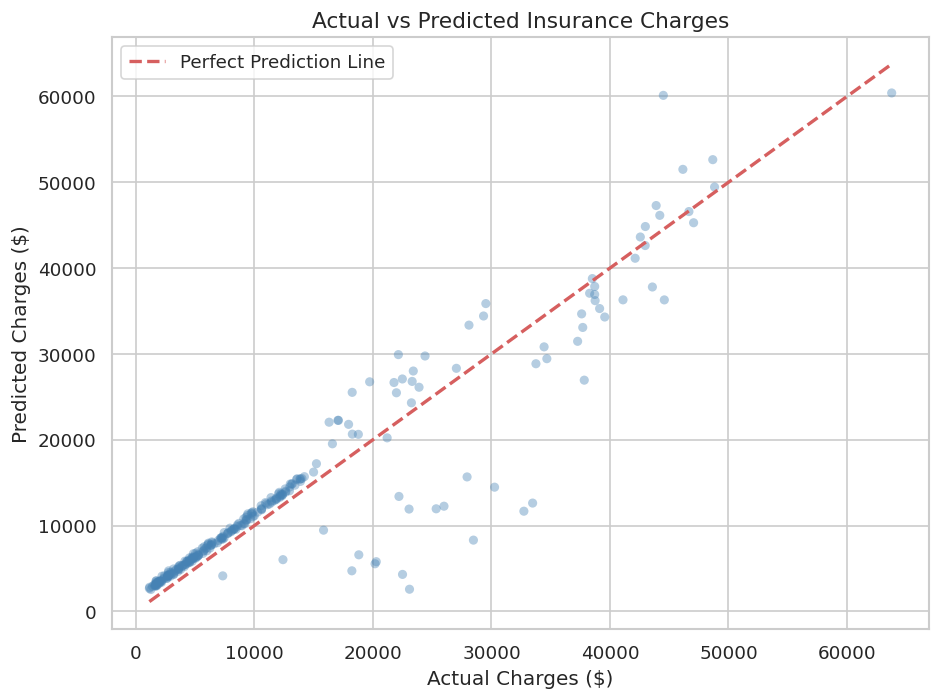

In [67]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

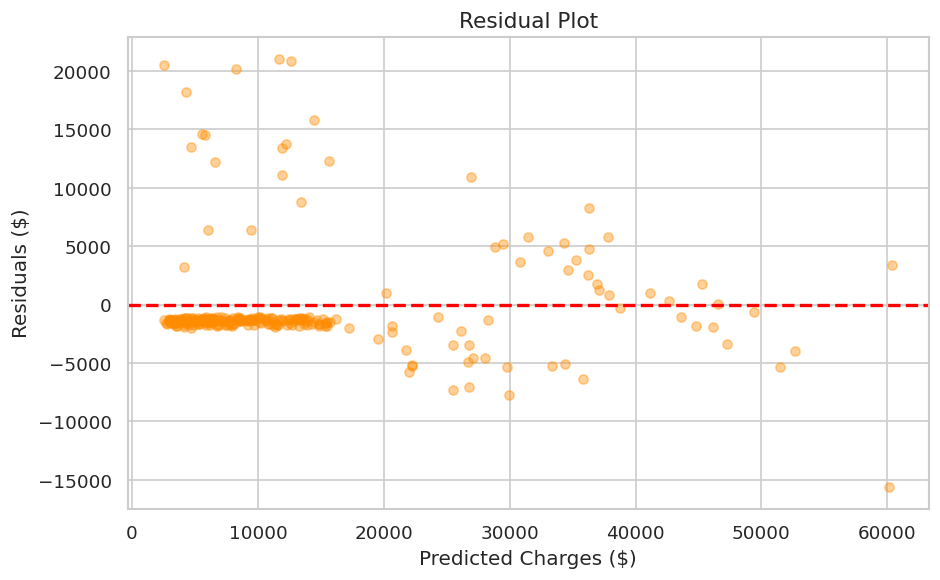

In [68]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='darkorange', s=30)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


In [70]:
print("══════════════════════════════════════════")
print("            FINAL PROJECT SUMMARY")
print("══════════════════════════════════════════")
print(f"  Dataset          : {df.shape[0]} samples, {X.shape[1]} features")
print(f"  Model            : Linear Regression")
print(f"  MAE              : ${mae:,.2f}")
print(f"  RMSE             : ${rmse:,.2f}")
print(f"  R² Score         : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  Cross-Val R²     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("══════════════════════════════════════════")
print("\n  Top Predictors of Insurance Charges:")
print("  1. Smoker status  — single strongest factor (~3-4x charges)")
print("  2. BMI × Smoker   — interaction: obese smokers pay most")
print("  3. Age            — charges rise steadily with age")
print("  4. BMI            — moderate effect for non-smokers")

══════════════════════════════════════════
            FINAL PROJECT SUMMARY
══════════════════════════════════════════
  Dataset          : 1338 samples, 10 features
  Model            : Linear Regression
  MAE              : $2,755.47
  RMSE             : $4,537.67
  R² Score         : 0.8674  (86.7% variance explained)
  Cross-Val R²     : 0.8396 ± 0.0312
══════════════════════════════════════════

  Top Predictors of Insurance Charges:
  1. Smoker status  — single strongest factor (~3-4x charges)
  2. BMI × Smoker   — interaction: obese smokers pay most
  3. Age            — charges rise steadily with age
  4. BMI            — moderate effect for non-smokers
